# Plot multi-lead predictions for predicting hurricane track (distance) errors.
author: Elizabeth A. Barnes and Randal J. Barnes

In [1]:
import sys

import pandas as pd

sys.path.append("..")

import importlib as imp

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from scipy.stats import multivariate_normal
from silence_tensorflow import silence_tensorflow
import pandas as pd

import cmasher as cmr
import plots

import experiment_settings
import mahalanobis
from build_data import build_hurricane_data
import data_info

In [2]:
__author__ = "Randal J Barnes and Elizabeth A. Barnes"
__version__ = "07 September 2022"

silence_tensorflow()
tf.config.set_visible_devices([], "GPU")  # turn-off tensorflow-metal if it is on

DATA_PATH = "../data/"
MODEL_PATH = "saved_models/"
FIGURE_PATH = "figures/analysis_plots/"

In [3]:
mpl.rcParams["figure.facecolor"] = "white"
dpiFig = 300.0
np.warnings.filterwarnings("ignore", category=np.VisibleDeprecationWarning)

In [4]:
EXP_NAME_VEC = ("centered_bivariate_normal_101_EPCP24",
                "centered_bivariate_normal_102_EPCP48",
                "centered_bivariate_normal_103_EPCP72",
                "centered_bivariate_normal_104_EPCP96",
                "centered_bivariate_normal_105_EPCP120",
                )
RNG_SEED = 123
TESTING_YEAR = 2018

In [5]:
# GET PREDICTIONS
df_pred_train = pd.DataFrame()
df_pred_valtest = pd.DataFrame()
df_pred_test = pd.DataFrame()

for exp_name in EXP_NAME_VEC:
    print(exp_name)
    settings = experiment_settings.get_settings(exp_name)

    network_seed = RNG_SEED
    settings["rng_seed"] = RNG_SEED
    settings["years_test"] = (TESTING_YEAR,)
    (
        data_summary,
        x_train,
        onehot_train,
        x_val,
        onehot_val,
        x_test,
        onehot_test,
        x_valtest,
        onehot_valtest,
        df_train,
        df_val,
        df_test,
        df_valtest,
    ) = build_hurricane_data(DATA_PATH, settings, verbose=0)

    # load the model
    model_name = (
            exp_name
            + "_"
            + str(TESTING_YEAR)
            + "_"
            + settings["uncertainty_type"]
            + "_"
            + f"network_seed_{network_seed}_rng_seed_{settings['rng_seed']}"
    )
    model = tf.keras.models.load_model(MODEL_PATH + model_name + "_model", compile=False)

    # make dictionary of the predictions
    pred_dict_lead = {"exp_name": exp_name,
                      "testing_year": TESTING_YEAR,
                      }

    # copy dataframe and fill in the predictions
    df_train_lt = df_train.copy()
    df_valtest_lt = df_valtest.copy()
    df_test_lt = df_test.copy()

    df_train_lt[["mu_u", "mu_v", "sigma_u", "sigma_v", "rho"]] = model.predict(x_train)
    df_valtest_lt[["mu_u", "mu_v", "sigma_u", "sigma_v", "rho"]] = model.predict(x_valtest)
    df_test_lt[["mu_u", "mu_v", "sigma_u", "sigma_v", "rho"]] = model.predict(x_test)

    df_train_lt["exp_name"] = exp_name
    df_valtest_lt["exp_name"] = exp_name
    df_test_lt["exp_name"] = exp_name

    df_pred_train = pd.concat([df_pred_train, df_train_lt], axis=0)
    df_pred_valtest = pd.concat([df_pred_valtest, df_valtest_lt], axis=0)
    df_pred_test = pd.concat([df_pred_test, df_test_lt], axis=0)

centered_bivariate_normal_101_EPCP24
centered_bivariate_normal_102_EPCP48
centered_bivariate_normal_103_EPCP72
centered_bivariate_normal_104_EPCP96
centered_bivariate_normal_105_EPCP120


In [6]:
# error('here')

# Plot Results

In [7]:
# N_COLORS = 50
# colors = ("#D95980", "#284E60", "#284E60", "#C3B1E1", "#351F27", "#A9C961")
plots.set_plot_rc()

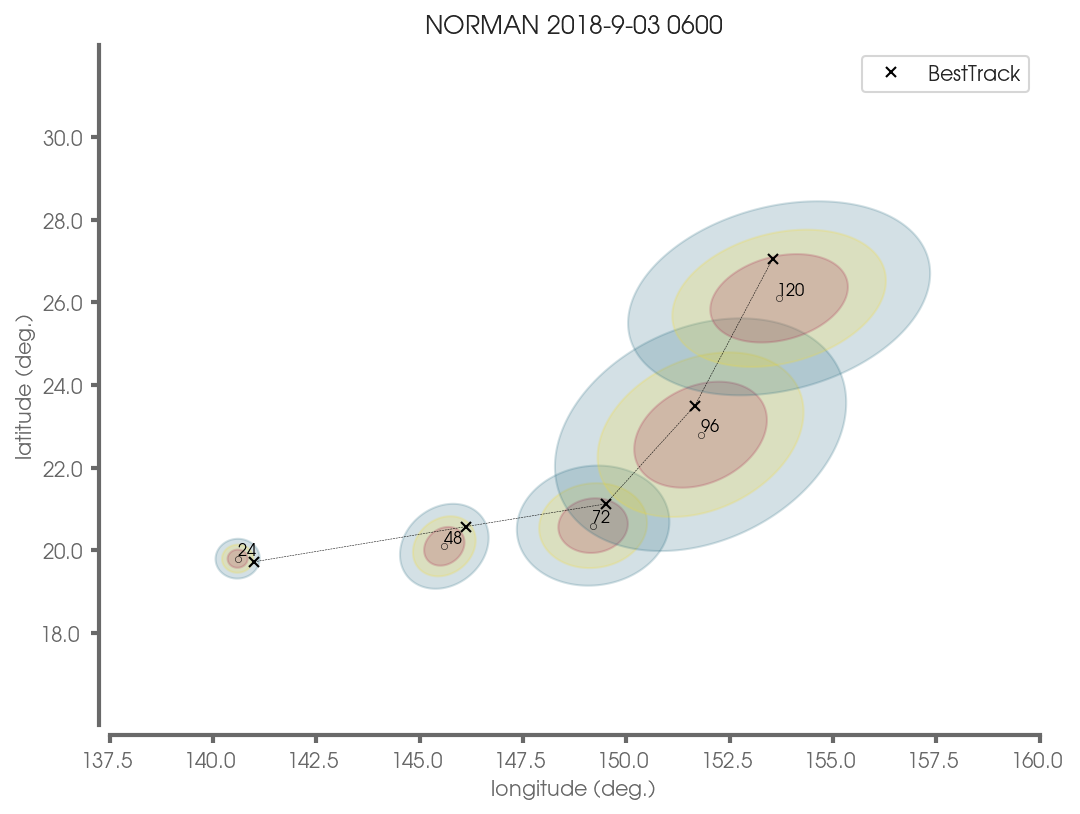

In [24]:
imp.reload(mahalanobis)

storm_name = "NORMAN"
pred_time = 90306
KM_TO_DEG = 1. / 111

# COLOR = cmr.take_cmap_colors("cmr.pride", 9, cmap_range=(0.2, 0.8), return_fmt="hex")
COLOR = cmr.take_cmap_colors("cmr.pride", 3, cmap_range=(0.2, 0.8), return_fmt="hex")
fig, ax = plt.subplots(1, 1, figsize=(8, 6), dpi=150)

# get the storm
LEADTIMES = [24, 48, 72, 96, 120]
df_storm = df_pred_test.loc[(df_pred_test["Name"] == storm_name) & (df_pred_test["time"] == pred_time)]

for lead_time in LEADTIMES:
    df = df_storm.loc[(df_storm["ftime(hr)"] == lead_time)]
    if df.empty:
        print(str(lead_time) + ' dataframe is empty')
        continue
    # display(df[["Name", "time", "ftime(hr)", "LONC", "LATC", "OBDX", "OBDY", "mu_u", "mu_v", "sigma_u", "sigma_v", "rho"]])

    besttrack_u = df["LONC"].values - KM_TO_DEG * df["OBDX"].values
    besttrack_v = df["LATC"].values - KM_TO_DEG * df["OBDY"].values

    mahalanobis.plot_cdf(
        df["LONC"].values - KM_TO_DEG * df["mu_u"].values,
        df["LATC"].values - KM_TO_DEG * df["mu_v"].values,
        KM_TO_DEG * df["sigma_u"].values,
        KM_TO_DEG * df["sigma_v"].values,
        df["rho"].values,
        besttrack_u=besttrack_u,
        besttrack_v=besttrack_v,
        colors=COLOR,
        contours=(.25, .5, .75),
    )

    # plot consensus prediction
    plt.plot(df["LONC"].values,
             df["LATC"].values,
             marker='o',
             markerfacecolor='None',
             markeredgewidth=.25,
             linestyle='',
             markersize=3,
             color='k',
             label='Consensus'
             )

    plt.text(df["LONC"].values,
             df["LATC"].values,
             df['ftime(hr)'].values[0],
             color="k",
             fontsize=8,
             horizontalalignment='left',
             verticalalignment='bottom',
             )

# connect the besttrack predictions
plt.plot(
    df_storm["LONC"].values - KM_TO_DEG * df_storm["OBDX"].values,
    df_storm["LATC"].values - KM_TO_DEG * df_storm["OBDY"].values,
    "--",
    linewidth=.25,
    color="k",
)

# format plot
plots.format_spines(ax)
plt.grid(None)

# set the axes and ticks
plt.xlabel('longitude (deg.)')
plt.ylabel('latitude (deg.)')

yticks = np.around(ax.get_yticks(), 3)
ax.set_yticks(yticks)
ax.set_yticklabels(yticks)
xticks = np.around(ax.get_xticks(), 3)
ax.set_xticks(xticks)
ax.set_xticklabels(xticks)

# setup legend
plt.legend()
handles, labels = plt.gca().get_legend_handles_labels()
plt.gca().legend(handles[:1], labels[:1])

# set storm title
details = data_info.get_storm_details(df, 0)
details = details[:details.rfind(' @')]
plt.title(details)

# save the figure
plt.savefig(FIGURE_PATH + 'multi_lead_predictions_' + EXP_NAME_VEC[0] + '_' + details.replace(' ', '_') + '.png',
            dpi=dpiFig,
            bbox_inches='tight',
            )
plt.show()